In [35]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout,Input

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [36]:
dataset_path = "Garbage classification"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

print("Classes:", train_dataset.class_names)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [37]:
classes = train_dataset.class_names

train_dataset = train_dataset.map(lambda x, y: (x / 255.0, y))

validation_dataset = validation_dataset.map(lambda x, y: (x / 255.0, y))

In [38]:
model = Sequential()

model.add(Input(shape=(128, 128, 3)))

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(64, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(6, activation='softmax'))

In [39]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [40]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,706,246 (14.14 MB)

 Trainable params: 3,706,246 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.fit(train_dataset,epochs=15
          ,validation_data=validation_dataset)

loss, accuracy = model.evaluate(validation_dataset)

print("Accuracy:", accuracy)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.2962 - loss: 1.7832 - val_accuracy: 0.3089 - val_loss: 1.6699
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.4045 - loss: 1.4828 - val_accuracy: 0.4416 - val_loss: 1.3903
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.4570 - loss: 1.3768 - val_accuracy: 0.4317 - val_loss: 1.3221
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - accuracy: 0.4980 - loss: 1.2655 - val_accuracy: 0.4475 - val_loss: 1.2955
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - accuracy: 0.5415 - loss: 1.1670 - val_accuracy: 0.5188 - val_loss: 1.2417
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - accuracy: 0.5831 - loss: 1.0772 - val_accuracy: 0.5604 - val_loss: 1.1439
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - accuracy: 0.6098 - loss: 0.9884 - val_accuracy: 0.5347 - val_loss: 1.1566
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - accuracy: 0.6365 - loss: 0.9251 - val_accuracy: 0.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Image 1
Actual    : glass
Predicted : metal
------------------------------


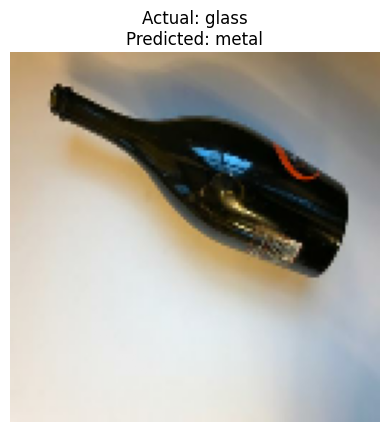

Image 2
Actual    : glass
Predicted : glass
------------------------------


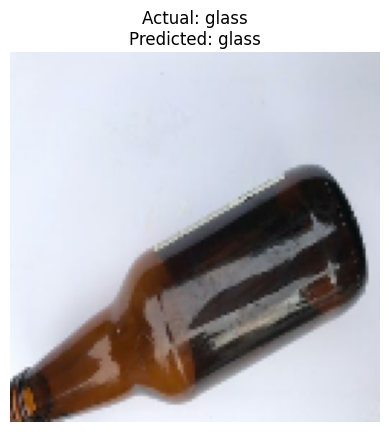

Image 3
Actual    : paper
Predicted : metal
------------------------------


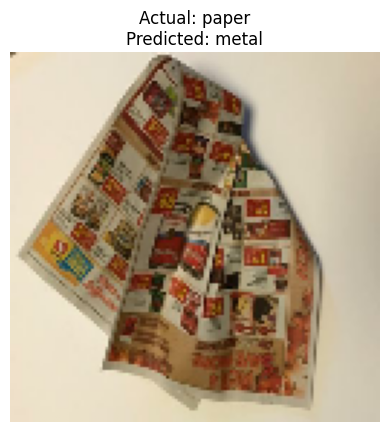

Image 4
Actual    : cardboard
Predicted : plastic
------------------------------


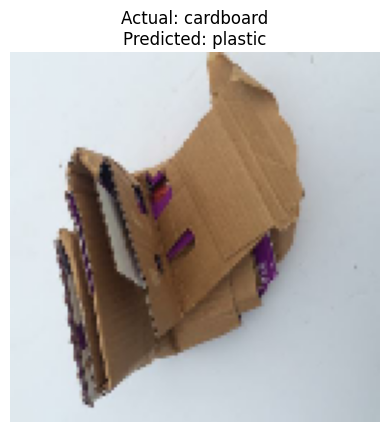

Image 5
Actual    : glass
Predicted : glass
------------------------------


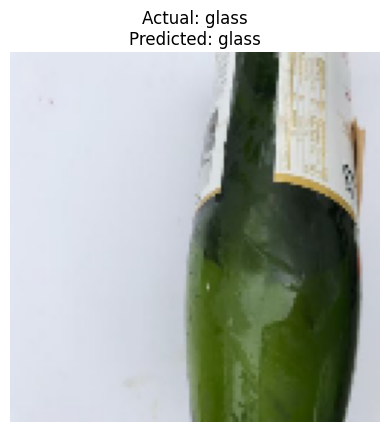

In [42]:
images, labels = next(iter(validation_dataset))

predictions = model.predict(images[:5])

for i in range(5):

    predicted_label = np.argmax(predictions[i])

    actual_label = labels[i].numpy()

    print(f"Image {i+1}")
    print(f"Actual    : {classes[actual_label]}")
    print(f"Predicted : {classes[predicted_label]}")
    print("-" * 30)

    plt.imshow(images[i])

    plt.title(f"Actual: {classes[actual_label]}\n"f"Predicted: {classes[predicted_label]}")

    plt.axis("off")
    plt.show()